# Xenium Prime 5K (codeword)

This notebook demonstrates essential steps for analyzing spatial codeword (exon/junction probes) usage in **Xenium Prime 5K data**, using [the 10x Genomics Xenium Prime 5K Mouse Brain Coronal dataset](https://www.10xgenomics.com/datasets/xenium-prime-fresh-frozen-mouse-brain) as an example.

1. Load codeword-level quantification as binned spatial data.
2. Run FFT-accelerated spatial variability tests with `SplisosmFFT`.
3. Compare results across spatial resolutions and with `SplisosmNP`.

For differential usage testing with `SplisosmFFT`, see the [Visium HD FFPE (probe) Part II tutorial](./visiumhd_ffpe_du.ipynb). Additionally, a `SplisosmNP`-based workflow using cell-segmentation results is available in the [Single-cell segmented data (Xenium Prime 5K) tutorial](./xenium_sc_segmented.ipynb).

Estimated runtime: ~5 min.

## Preliminary notes

For Xenium Prime 5K datasets, each gene is profiled by multiple [codewords (i.e., exon/junction probe sets)](https://www.10xgenomics.com/support/software/xenium-panel-designer/latest/tutorials/xenium-panel-design-concepts-terms#codewords). This notebook uses the same Xenium dataset as presented in the SPLISOSM paper and as in the [Single-cell segmented data tutorial](./xenium_sc_segmented.ipynb).

- The dataset can be downloaded from 10x Genomics [here](https://www.10xgenomics.com/datasets/xenium-prime-fresh-frozen-mouse-brain)
- Probe set (5K Mouse Pan Tissue and Pathways Panel) information is available [here](https://www.10xgenomics.com/support/software/xenium-panel-designer/latest/tutorials/pre-designed-xenium-prime-5k). 

After downloading Xenium analysis outputs, we reran the **Xenium Ranger v3.1.0 relabel pipeline** to get codeword transcript counts. Due to Xenium output data structure changes, if you encounter issues, consider re-running the Xenium Ranger (**v3.1.0+**) relabel pipeline as well. See [10x documentation](https://www.10xgenomics.com/support/software/xenium-ranger/latest/analysis/running-pipelines/XR-relabel) for guidance.

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import spatialdata as sd
import spatialdata_plot  # Registers plotting accessors
from spatialdata import rasterize_bins

from splisosm import SplisosmFFT, SplisosmNP
from splisosm.utils import counts_to_ratios
from splisosm.io import load_xenium_codeword

In [2]:
warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (6, 4)

## Configure paths and core parameters

In [3]:
# Required: Xenium Ranger output directory (either the `outs` dir itself or its parent)
xenium_prime_outs = Path('/path/to/xenium_prime_5k/outs')

# Optional cache path
sdata_zarr = xenium_prime_outs / 'sdata_codeword.filtered.zarr'

# Optional probe annotation BED for visualization
bed_file = Path("/path/to/xenium_5k_probe_locations.bed")
# Optional gene annotation GTF for gene symbol mapping
gtf_file = Path("/path/to/mm10/gencode.vM23.annotation.gtf.gz")

# Resolutions (um) to materialize
spatial_resolutions = [8.0, 16.0]

# Primary analysis table / bins
test_table = 'square_016um'
test_bins_element = 'square_016um_bins'

# Feature grouping and filters
group_iso_by = 'gene_symbol'
gene_name_col = 'gene_symbol'
min_counts = 10
min_bin_pct = 0.0

# Xenium transcript filter
quality_threshold = 20.0

In [4]:
# local path
xenium_prime_outs = Path('/Users/jysumac/Projects/SPLISOSM_paper/data/xenium_5k_mouse_brain/codeword-relabel/outs')
bed_file = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/xenium_5k_mouse_brain/xenium_mouse_5K_gene_expression_panel_probe_locations.bed")
gtf_file = Path("/Users/jysumac/reference/mm10/gencode.vM23.annotation.gtf.gz")

## Load codeword-level `SpatialData`

We use `splisosm.io.load_xenium_codeword` to read `transcripts.zarr.zip` directly and optionally bin transcripts into square units of fixed resolutions.


In [5]:
%%time
if sdata_zarr.exists():
    print('Loading cached SpatialData...')
    sdata = sd.read_zarr(sdata_zarr)
else:
    print('Building Xenium codeword SpatialData from transcript chunks...')
    sdata = load_xenium_codeword(
        path=xenium_prime_outs,
        spatial_resolutions=spatial_resolutions,
        quality_threshold=quality_threshold,
        n_jobs=-1,
        chunk_batch_size=64,
        counts_layer_name='counts',
        build_cell_codeword_table=True,
        create_square_shapes=True,
        show_progress=True,
    )
    # Optional: cache for faster reruns
    # sdata.write(sdata_zarr)

sdata

Building Xenium codeword SpatialData from transcript chunks...


/Users/jysumac/miniforge3/envs/splisosm_dev/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


Binning codewords @ 8um (576 chunks):   0%|          | 0/9 [00:00<?, ?it/s]

Binning codewords @ 8um (576 chunks):  11%|█         | 1/9 [00:00<00:04,  1.66it/s]

...

Binning codewords @ 16um (576 chunks):  78%|███████▊  | 7/9 [00:07<00:02,  1.01s/it]

Binning codewords @ 16um (576 chunks):  89%|████████▉ | 8/9 [00:08<00:01,  1.02s/it]

Binning codewords @ 16um (576 chunks): 100%|██████████| 9/9 [00:09<00:00,  1.07s/it]

CPU times: user 3min 19s, sys: 51 s, total: 4min 10s
Wall time: 1min 46s


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 23912, 34154), (4, 11956, 17077), (4, 5978, 8538), (4, 2989, 4269), (4, 1494, 2134)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (23912, 34154), (11956, 17077), (5978, 8538), (2989, 4269), (1494, 2134)
│     └── 'nucleus_labels': DataTree[yx] (23912, 34154), (11956, 17077), (5978, 8538), (2989, 4269), (1494, 2134)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (63173, 1) (2D shapes)
│     ├── 'nucleus_boundaries': GeoDataFrame shape: (63036, 1) (2D shapes)
│     ├── 'square_008um_bins': GeoDataFrame shape: (576580, 1) (2D shapes)
│     └── 'square_016um_bins': GeoDataFrame shape: (144372, 1) (2D shapes)
└── Tables
      ├── 'square_008um': AnnData (576580, 11163)
      ├── 'square_016um': AnnData (144372, 11163)
      ├── 'table': AnnData (63173, 5006)
      └── 'table_codeword': AnnData (63173, 11163)
with 

In Xenium Prime 5K datasets, each codeword corresponds to a specific probe set for a gene. 
Here, we will focus on the codeword-level counts tables:
- `sdata.tables['table_codeword']` contains cell-by-codeword counts aggregated to segmented cells.
- `sdata.tables['square_*um']` contains bin-by-codeword counts aggregated at various resolutions.

In [6]:
def summarize_table(adata):
    X = adata.layers['counts'] if 'counts' in adata.layers else adata.X
    if hasattr(X, 'nnz'):
        nnz = int(X.nnz)
        total = int(X.shape[0] * X.shape[1])
        density = nnz / total if total else np.nan
    else:
        arr = np.asarray(X)
        nnz = int(np.count_nonzero(arr))
        total = int(arr.size)
        density = nnz / total if total else np.nan
    return {
        'n_features': int(adata.n_vars),
        'n_bins': int(adata.n_obs),
        'count_mtx_density': density,
    }

rows = []
for key in sorted(sdata.tables.keys()):
    rows.append({'table': key, **summarize_table(sdata.tables[key])})

table_summary = pd.DataFrame(rows).sort_values('table')
table_summary

,table,n_features,n_bins,count_mtx_density
0,square_008um,11163,576580,0.018701
1,square_016um,11163,144372,0.058018
2,table,5006,63173,0.139117
3,table_codeword,11163,63173,0.077513


Note that only data with regular spacing (e.g., `square_016um`) are suitable for FFT-based spatial variability analysis. 
For illustration purposes, we will run analysis on the `square_016um` table and use the shape `square_016um_bins` (i.e., spatial grid with 16x16um bins) for rasterization.

In [7]:
print('Tables:', sorted(sdata.tables.keys()))
print('Shapes:', sorted(getattr(sdata, 'shapes', {}).keys()))
print('Images:', sorted(getattr(sdata, 'images', {}).keys()))

if test_table not in sdata.tables:
    raise ValueError(f'{test_table} is not available. Choose from: {sorted(sdata.tables.keys())}')
if test_bins_element not in sdata.shapes:
    raise ValueError(f'{test_bins_element} is not available. Choose from: {sorted(sdata.shapes.keys())}')

adata_test = sdata.tables[test_table]
if group_iso_by not in adata_test.var.columns:
    raise ValueError(f'{group_iso_by} not found in {test_table}.var columns')

print(f'Using table={test_table}, bins={test_bins_element}')
print(f'Grouping column={group_iso_by}, display names={gene_name_col}')

Tables: ['square_008um', 'square_016um', 'table', 'table_codeword']
Shapes: ['cell_boundaries', 'nucleus_boundaries', 'square_008um_bins', 'square_016um_bins']
Images: ['morphology_focus']
Using table=square_016um, bins=square_016um_bins
Grouping column=gene_symbol, display names=gene_symbol


## Morphology and segmentation preview

/Users/jysumac/miniforge3/envs/splisosm_dev/lib/python3.12/site-packages/pims/tiff_stack.py:131: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  data = t.asarray()


CPU times: user 5min 36s, sys: 29.9 s, total: 6min 6s
Wall time: 57.6 s


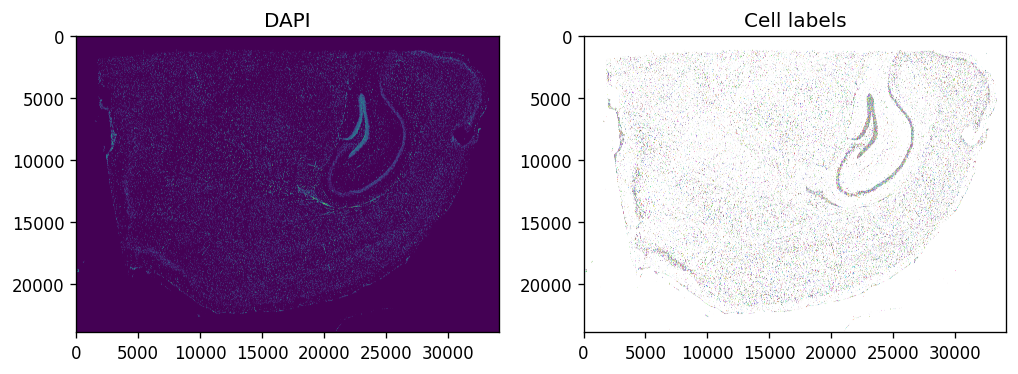

In [8]:
%%time
axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_images(f"morphology_focus", channel='DAPI').pl.show(
    coordinate_systems=f"global",
    ax=axes[0], title="DAPI", colorbar=False
)
sdata.pl.render_labels(f"cell_labels").pl.show(
    coordinate_systems=f"global",
    ax=axes[1], title="Cell labels"
)

## Rasterize bins and visualize one codeword

In [9]:
%%time
# rasterize_bins() expects a CSC matrix for best compatibility
adata_plot = sdata.tables[test_table]
adata_plot.X = adata_plot.layers['counts']
if hasattr(adata_plot.X, 'tocsc') and getattr(adata_plot.X, 'format', None) != 'csc':
    adata_plot.X = adata_plot.X.tocsc()

raster_key = f'rasterized_{test_table}'
sdata[raster_key] = rasterize_bins(
    sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key='array_col',
    row_key='array_row',
)
print('Created:', raster_key)

Created: rasterized_square_016um
CPU times: user 889 ms, sys: 314 ms, total: 1.2 s
Wall time: 1.28 s


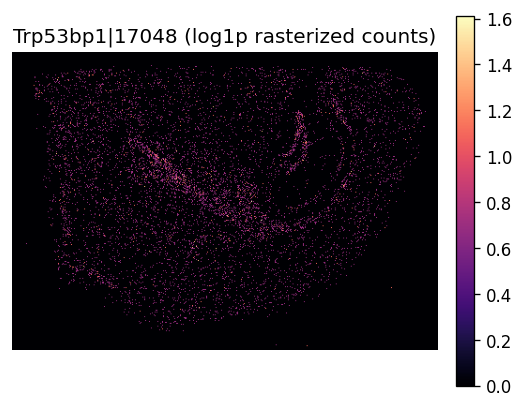

CPU times: user 41.8 ms, sys: 7.14 ms, total: 49 ms
Wall time: 48.4 ms


In [10]:
%%time
feature_name = 'Trp53bp1|17048' # Trp53bp1
img = np.asarray(sdata[f'rasterized_{test_table}'].sel(c=feature_name).values).squeeze()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(np.log1p(img), cmap='magma')
ax.set_title(f'{feature_name} (log1p rasterized counts)')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Spatial variability testing with `SplisosmFFT`

In [11]:
model = SplisosmFFT(neighbor_degree=1, rho=0.99)
model.setup_data(
    sdata=sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key='array_col',
    row_key='array_row',
    layer='counts',
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True
)
model

=== SplisosmFFT
- Number of genes: 4972
- Number of spots: 144372
- Number of spots after rasterization: 144372
- Number of covariates: 0
- Average isoforms per gene: 2.1
=== Model configurations
- Neighborhood degree: 1
- Spatial autocorrelation rho: 0.99
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

Before running the test, we can again check gene-level summaries to confirm that Xenium Prime 5K data contains multiple codewords per gene.

In [12]:
%%time
gene_meta = model.extract_feature_summary(level='gene')
gene_meta.sort_values('perplexity', ascending=False).head(5)

Genes:   0%|          | 0/4972 [00:00<?, ?it/s]

Genes:   2%|▏         | 87/4972 [00:00<00:05, 868.63it/s]

Genes:   4%|▍         | 191/4972 [00:00<00:04, 968.26it/s]

Genes:   6%|▌         | 288/4972 [00:00<00:05, 915.25it/s]

Genes:   8%|▊         | 399/4972 [00:00<00:04, 985.10it/s]

...

Genes:  96%|█████████▌| 4775/4972 [00:05<00:00, 1010.83it/s]

Genes:  98%|█████████▊| 4878/4972 [00:05<00:00, 1012.59it/s]

Genes: 100%|██████████| 4972/4972 [00:05<00:00, 952.11it/s] 

CPU times: user 5.13 s, sys: 765 ms, total: 5.89 s
Wall time: 5.93 s


,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
gene,,,,,,
Gnao1,4,3.979105,0.616671,4.027173,5.066839,0.292012
Apob,4,3.952770,0.001385,0.002016,0.141543,0.288660
Gja1,4,3.929913,0.375149,1.565989,3.772387,0.333883
Acox1,4,3.921495,0.459334,1.000139,1.440174,0.301513
Ghr,4,3.909349,0.041268,0.045805,0.233034,0.308937


In [13]:
%%time
model.test_spatial_variability(
    method='hsic-ir',
    ratio_transformation='none',
    n_jobs=-1,
    print_progress=True,
)
sv_res_fft = model.get_formatted_test_results(
    'sv', with_gene_summary=True
).sort_values('pvalue_adj')

SV [hsic-ir]:   0%|          | 0/4972 [00:00<?, ?it/s]

SV [hsic-ir]:   1%|          | 30/4972 [00:00<00:18, 260.15it/s]

SV [hsic-ir]:   1%|          | 57/4972 [00:00<00:22, 221.40it/s]

SV [hsic-ir]:   2%|▏         | 80/4972 [00:00<00:32, 150.18it/s]

SV [hsic-ir]:   2%|▏         | 100/4972 [00:00<00:37, 130.34it/s]

...

SV [hsic-ir]: 100%|█████████▉| 4950/4972 [00:52<00:00, 93.03it/s]

SV [hsic-ir]: 100%|█████████▉| 4960/4972 [00:52<00:00, 93.99it/s]

SV [hsic-ir]: 100%|█████████▉| 4970/4972 [00:53<00:00, 94.73it/s]

SV [hsic-ir]: 100%|██████████| 4972/4972 [00:53<00:00, 93.72it/s]

CPU times: user 2min 18s, sys: 26 s, total: 2min 44s
Wall time: 53.2 s


In [14]:
sig_001 = int((sv_res_fft['pvalue_adj'] < 0.01).sum())
print(
    'Spatially variable genes (FDR < 0.01): '
    f'{sig_001} out of {sv_res_fft.shape[0]} total genes'
)
sv_res_fft.head(5)

Spatially variable genes (FDR < 0.01): 2158 out of 4972 total genes


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
1230,Pja1,2.192375e-06,0.0,0.0,2,1.980112,0.230211,0.328949,0.703162,0.570571
643,Fap,1.540108e-07,0.0,0.0,3,2.600355,0.011837,0.013257,0.130763,0.509404
2978,Syne1,4.315414e-06,0.0,0.0,2,1.999256,0.303037,0.593363,1.207081,0.513640
673,Cyp26b1,1.980515e-07,0.0,0.0,2,1.409796,0.022560,0.038865,0.374784,0.891463
3648,Vamp2,2.441610e-06,0.0,0.0,2,1.995571,0.602575,3.061141,3.648642,0.533281


We can use negative control probes to estimate false positive rates due to technical noise (e.g., probe malfunction or non-specific hybridization).

In [15]:
ctrl_genes = (
    sv_res_fft['gene'].str.startswith('NegControlProbe') |
    sv_res_fft['gene'].str.startswith('Intergenic')
)
sig_001_ctrl = int((sv_res_fft.loc[ctrl_genes, 'pvalue_adj'] < 0.01).sum())
print(
    'Spatially variable negative control genes (FDR < 0.01): '
    f'{sig_001_ctrl} out of {sv_res_fft.loc[ctrl_genes].shape[0]} total control genes'
)
sv_res_fft.loc[ctrl_genes].sort_values('pvalue_adj').head(5)

Spatially variable negative control genes (FDR < 0.01): 9 out of 57 total control genes


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
2475,Intergenic_Region_105_part_73,2.199321e-08,5.841736e-17,4.277630e-16,3,2.321053,0.002625,0.002701,0.053352,0.551282
463,NegControlProbe_00041,5.502025e-09,1.514442e-07,6.413802e-07,2,1.266769,0.002944,0.003055,0.057399,0.936508
731,NegControlProbe_00003,5.328555e-09,2.520976e-07,1.040190e-06,3,1.655403,0.001365,0.001365,0.036914,0.857868
1042,Intergenic_Region_10757_part_30,8.702548e-09,7.845542e-05,2.456425e-04,3,2.391157,0.001081,0.001081,0.032854,0.608974
1105,NegControlProbe_00014,1.269646e-08,2.300467e-04,6.740084e-04,3,2.061472,0.002092,0.002092,0.045689,0.754967


## Visualize selected significant genes

In [16]:
def ensure_rasterized(sdata, bin_table: str, bin_element: str, layer: str = 'counts'):
    raster_key = f'rasterized_{bin_table}_{layer}'
    if raster_key in sdata.images:
        return raster_key

    adata = sdata.tables[bin_table]
    adata.X = adata.layers[layer]
    if hasattr(adata.X, 'tocsc') and getattr(adata.X, 'format', None) != 'csc':
        adata.X = adata.X.tocsc()

    sdata[raster_key] = rasterize_bins(
        sdata,
        bins=bin_element,
        table_name=bin_table,
        col_key='array_col',
        row_key='array_row',
    )
    return raster_key

In [17]:
def plot_gene_codeword_maps(
    sdata,
    bin_table: str,
    bin_element: str,
    gene_id: str,
    var_meta: pd.DataFrame | None = None,
    group_col: str = 'gene_symbol',
    max_features: int = 4,
    hide_zero_count: bool = True,
    hide_zero_ratio: bool = True,
):
    adata = sdata.tables[bin_table]
    if var_meta is None:
        var_meta = adata.var.copy()

    if group_col not in var_meta.columns:
        raise ValueError(f"'{group_col}' not found in var metadata columns")

    feature_names = var_meta.index[var_meta[group_col].astype(str) == str(gene_id)].tolist()
    if len(feature_names) == 0:
        raise ValueError(f"No features found for gene '{gene_id}'")

    feature_names = feature_names[: min(len(feature_names), max_features)]

    raster_key = ensure_rasterized(sdata, bin_table=bin_table, bin_element=bin_element)
    data = sdata[raster_key].sel(c=feature_names).values
    counts_cube = np.moveaxis(np.asarray(data, dtype=float), 0, -1)

    counts_flat = counts_cube.reshape(-1, counts_cube.shape[-1])
    ratios_flat = counts_to_ratios(counts_flat, transformation='none', nan_filling='none')
    ratios_cube = ratios_flat.numpy().reshape(counts_cube.shape)

    n_feat = counts_cube.shape[-1]
    fig, axes = plt.subplots(2, n_feat, figsize=(4 * n_feat, 7), squeeze=False)

    vmax_ratio = np.nanpercentile(ratios_cube, 99) if np.isfinite(ratios_cube).any() else 1.0

    for i, feature in enumerate(feature_names):
        c = counts_cube[:, :, i]
        r = ratios_cube[:, :, i]

        if hide_zero_count:
            c = np.where(c == 0, np.nan, c)
        if hide_zero_ratio:
            r = np.where(r == 0, np.nan, r)

        im0 = axes[0, i].imshow(np.log1p(c), cmap='Purples', vmin=0.0)
        axes[0, i].set_title(f'Count (log1p)\n{feature}')
        axes[0, i].axis('off')
        fig.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

        im1 = axes[1, i].imshow(r, cmap='Reds', vmin=0.0, vmax=vmax_ratio)
        axes[1, i].set_title(f'Ratio\n{feature}')
        axes[1, i].axis('off')
        fig.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

    fig.suptitle(f'Gene {gene_id} | showing {n_feat} features | {bin_table}', y=1.02)
    fig.tight_layout()
    plt.show()

In [18]:
top_genes = sv_res_fft.head(10)['gene'].astype(str).tolist()
top_genes[:5]

['Pja1', 'Fap', 'Syne1', 'Cyp26b1', 'Vamp2']

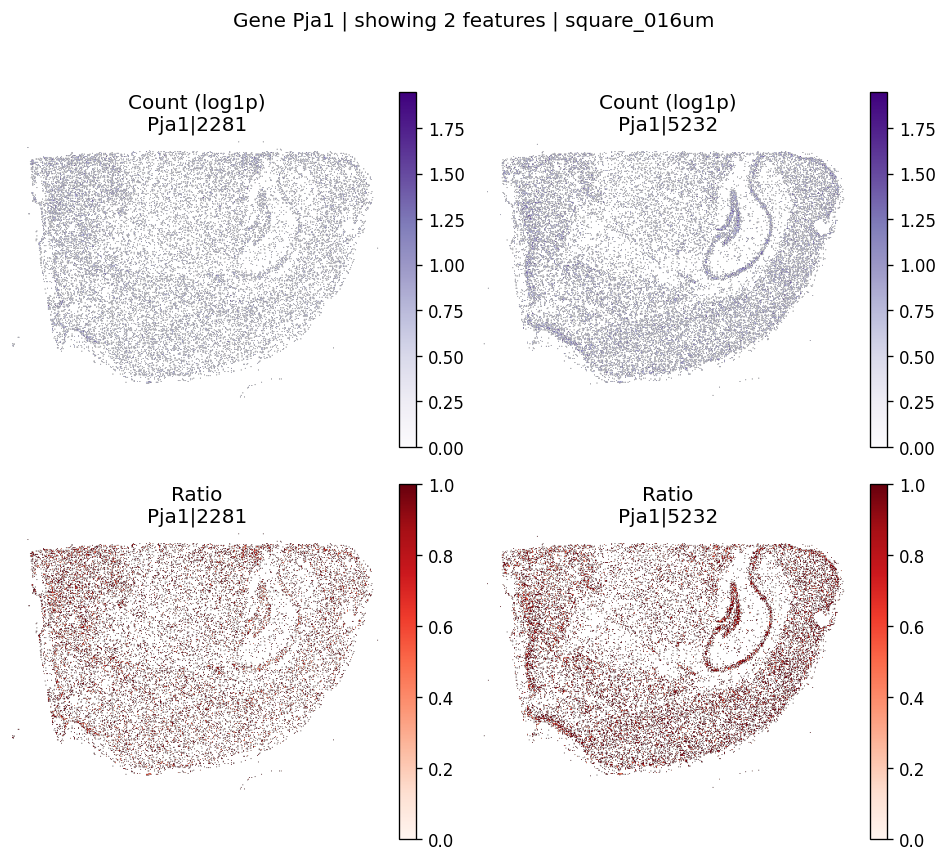

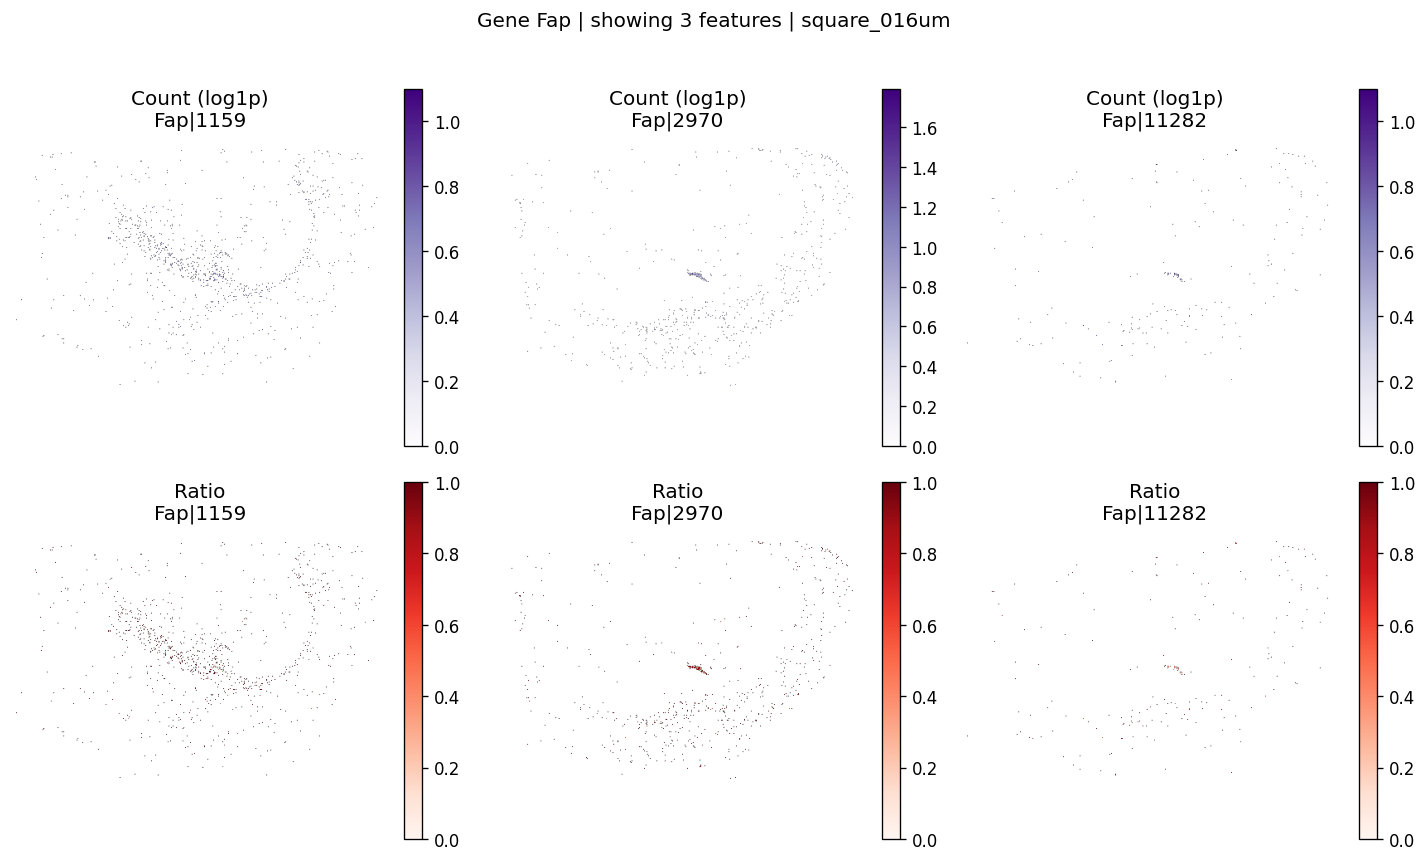

In [19]:
for gene_id in top_genes[:2]:
    plot_gene_codeword_maps(
        sdata=sdata,
        bin_table=test_table,
        bin_element=test_bins_element,
        gene_id=gene_id,
        var_meta=sdata.tables[test_table].var,
        group_col=group_iso_by,
        max_features=6,
        hide_zero_ratio=True,
    )

And also for negative control probes

In [20]:
top_ctrl_genes = sv_res_fft.loc[ctrl_genes].head(10)['gene'].astype(str).tolist()
top_ctrl_genes[:5]

['Intergenic_Region_105_part_73',
 'NegControlProbe_00041',
 'NegControlProbe_00003',
 'Intergenic_Region_10757_part_30',
 'NegControlProbe_00014']

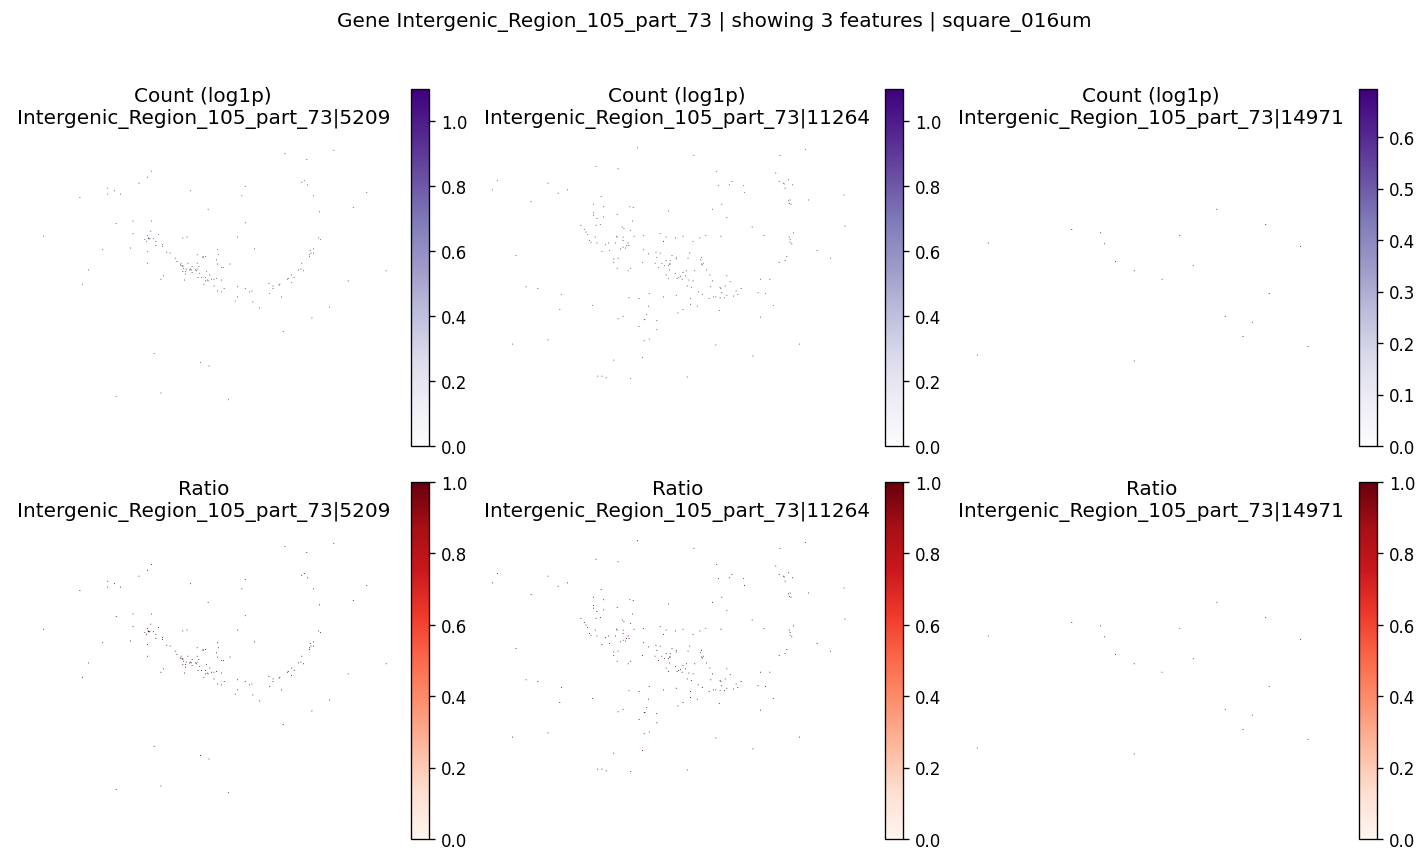

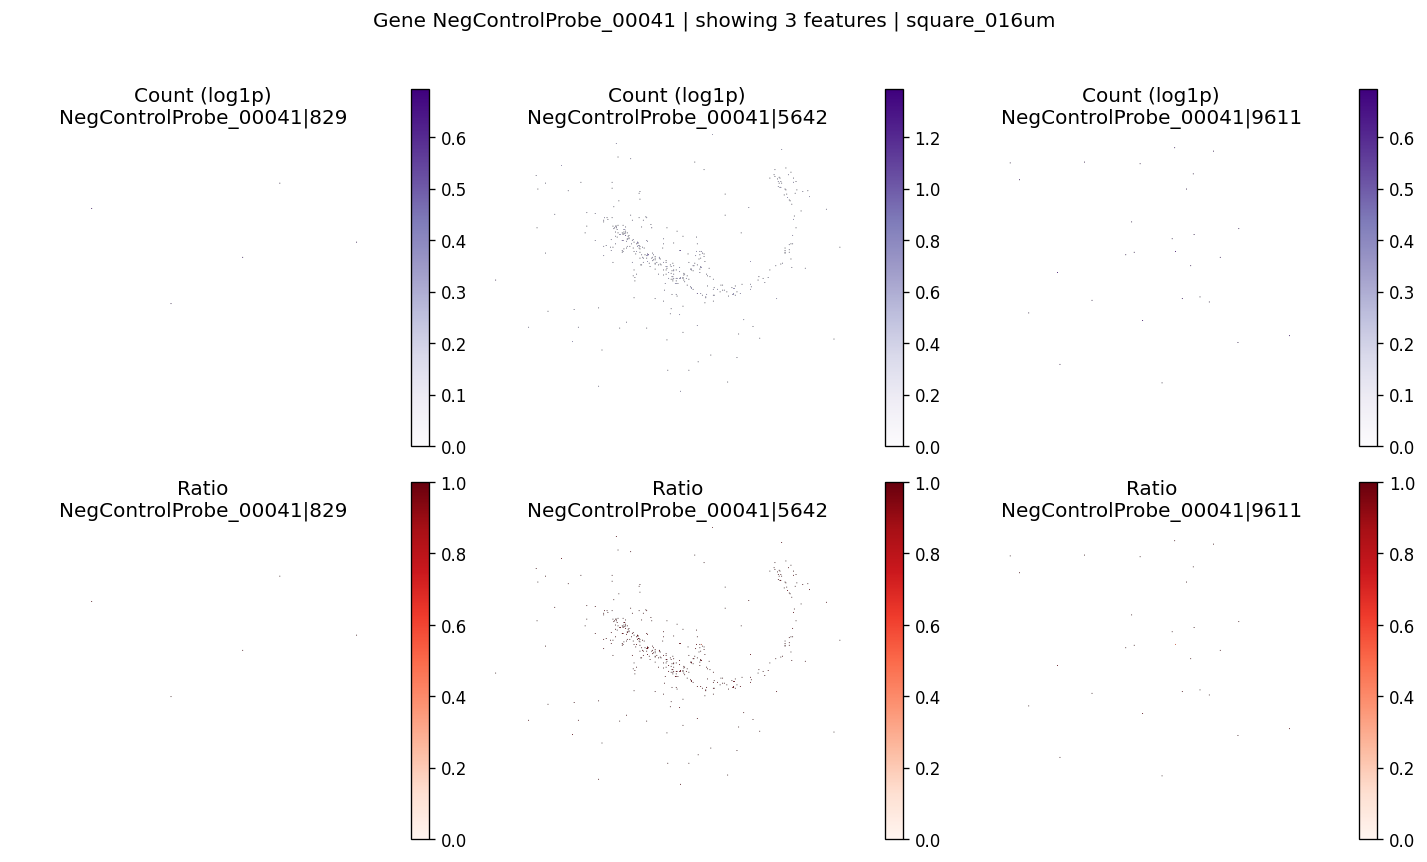

In [21]:
for gene_id in top_ctrl_genes[:2]:
    plot_gene_codeword_maps(
        sdata=sdata,
        bin_table=test_table,
        bin_element=test_bins_element,
        gene_id=gene_id,
        var_meta=sdata.tables[test_table].var,
        group_col=group_iso_by,
        max_features=6,
        hide_zero_ratio=True,
    )

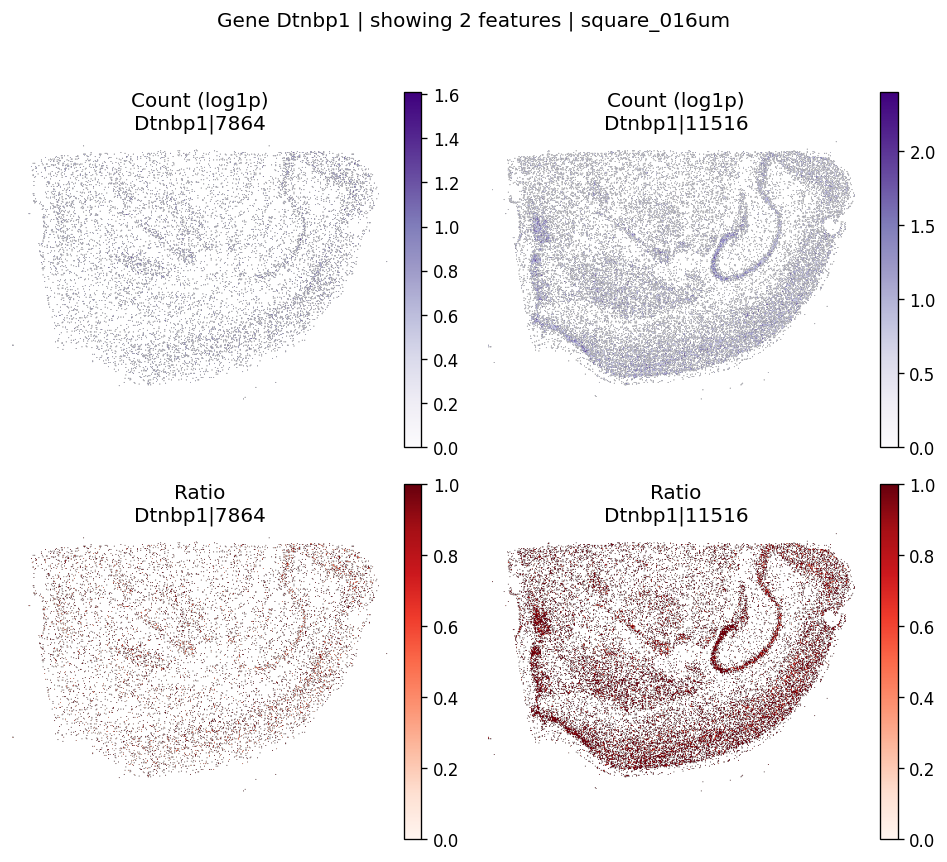

CPU times: user 165 ms, sys: 16.8 ms, total: 181 ms
Wall time: 181 ms


In [22]:
%%time
# Example: inspect a specific gene manually
plot_gene_codeword_maps(
    sdata=sdata,
    bin_table=test_table,
    bin_element=test_bins_element,
    gene_id='Dtnbp1',
    var_meta=sdata.tables[test_table].var,
    group_col=group_iso_by,
    max_features=6,
    hide_zero_ratio=True,
)

To see the spatially variable transcript regions, we can visualize the 10x reference probe sets along with a matched transcript reference. The following files need to be downloaded and provided as input:
- `xenium_mouse_5K_gene_expression_panel_probe_locations.bed` from [10x Genomics](https://www.10xgenomics.com/support/software/xenium-panel-designer/latest/tutorials/pre-designed-xenium-prime-5k)
- `gencode.vM23.annotation.gtf.gz` from [GENCODE](https://www.gencodegenes.org/mouse/releases.html)

In [23]:
def plot_codeword_transcript_structure(
    gene_name: str,
    bed_file: str | Path,
    gtf_file: str | Path,
    figsize: tuple[float, float] = (12, 6),
):
    """Visualize codeword probes and transcript exon structure for one gene."""
    import gzip

    bed_file = Path(bed_file)
    gtf_file = Path(gtf_file)

    # Parse BED12/bedDetail rows while skipping track/browser headers.
    bed_cols = [
        "chrom",
        "start",
        "end",
        "name",
        "score",
        "strand",
        "thickStart",
        "thickEnd",
        "itemRgb",
        "blockCount",
        "blockSizes",
        "blockStarts",
        "detail",
    ]
    bed_records: list[list[str]] = []
    with open(bed_file, "rt", encoding="utf-8") as handle:
        for line in handle:
            line = line.rstrip("\n")
            if not line or line.startswith("#") or line.startswith("track") or line.startswith("browser"):
                continue
            parts = line.split("\t")
            if len(parts) < 12:
                continue
            detail = parts[12] if len(parts) >= 13 else ""
            bed_records.append(parts[:12] + [detail])

    if not bed_records:
        warnings.warn(f"No valid BED12 rows found in {bed_file}")
        return

    bed_df = pd.DataFrame(bed_records, columns=bed_cols)
    numeric_cols = ["start", "end", "thickStart", "thickEnd", "blockCount"]
    for col in numeric_cols:
        bed_df[col] = pd.to_numeric(bed_df[col], errors="coerce").fillna(0).astype(int)

    # Extract gene symbol, gene id, and codeword id from Xenium probe naming.
    def parse_probe_fields(row: pd.Series) -> pd.Series:
        name_text = str(row["name"])
        detail_text = str(row.get("detail", ""))

        parts = [p.strip() for p in name_text.split("|")]
        gene_token = parts[0] if parts else name_text
        codeword_id = parts[1] if len(parts) >= 2 else ""

        gene_symbol = gene_token.split(" (", 1)[0].strip()
        gene_id = ""
        if "(" in gene_token and ")" in gene_token:
            gene_id = gene_token.split("(", 1)[1].split(")", 1)[0].strip()

        if (not codeword_id) and ("Codeword:" in detail_text):
            codeword_id = detail_text.split("Codeword:", 1)[1].split(",", 1)[0].strip()

        if not codeword_id:
            codeword_id = "NA"

        return pd.Series(
            {
                "gene_symbol": gene_symbol,
                "gene_id": gene_id,
                "codeword_id": codeword_id,
            }
        )

    parsed = bed_df.apply(parse_probe_fields, axis=1)
    bed_df = pd.concat([bed_df, parsed], axis=1)

    # Match by gene symbol, Ensembl gene ID, or generic name contains fallback.
    gene_key = str(gene_name).strip().lower()
    probes = bed_df[
        (bed_df["gene_symbol"].str.lower() == gene_key)
        | (bed_df["gene_id"].str.lower() == gene_key)
        | (bed_df["name"].str.lower().str.contains(gene_key, na=False))
    ].copy()

    if probes.empty:
        warnings.warn(f"No probes found for gene '{gene_name}' in {bed_file}")

    # Convert BED12 blocks to absolute genomic coordinates per probe row.
    def parse_blocks(row: pd.Series) -> list[tuple[int, int]]:
        starts = [int(x) for x in str(row["blockStarts"]).strip(",").split(",") if x != ""]
        sizes = [int(x) for x in str(row["blockSizes"]).strip(",").split(",") if x != ""]
        n = min(int(row["blockCount"]), len(starts), len(sizes))

        if n == 0:
            return [(int(row["start"]), int(row["end"]))]

        blocks = []
        for i in range(n):
            block_start = int(row["start"]) + starts[i]
            block_end = block_start + sizes[i]
            blocks.append((block_start, block_end))
        return blocks

    if not probes.empty:
        probes["blocks"] = probes.apply(parse_blocks, axis=1)

    # Read GTF and filter transcripts by gene symbol or gene id.
    if str(gtf_file).endswith(".gz"):
        gtf_opener = lambda f: gzip.open(f, "rt")
    else:
        gtf_opener = open

    transcripts_by_id = {}
    with gtf_opener(gtf_file) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 9:
                continue
            ftype, start, end = fields[2], int(fields[3]), int(fields[4])
            attrs = {}
            for attr in fields[8].split("; "):
                if " " in attr:
                    k, v = attr.split(" ", 1)
                    attrs[k] = v.strip('"')

            if attrs.get("gene_name", "").lower() != gene_key and attrs.get("gene_id", "").lower() != gene_key:
                continue

            tx_id = attrs.get("transcript_id", "unknown")
            if tx_id not in transcripts_by_id:
                tx_name = attrs.get("transcript_name", tx_id)
                transcripts_by_id[tx_id] = {
                    "chrom": fields[0],
                    "strand": fields[6],
                    "tx_name": tx_name,
                    "exons": [],
                }

            if ftype == "exon":
                transcripts_by_id[tx_id]["exons"].append((start, end))

    fig, ax = plt.subplots(figsize=figsize)

    # Plot transcripts first.
    y_pos = 0
    x_mins: list[int] = []
    x_maxs: list[int] = []

    strand_colors = {
        "+": "steelblue",
        "-": "darkorange",
    }

    if transcripts_by_id:
        for tx_id, tx_info in sorted(transcripts_by_id.items()):
            exons = sorted(tx_info["exons"])
            if not exons:
                continue

            min_coord = min(e[0] for e in exons)
            max_coord = max(e[1] for e in exons)
            x_mins.append(min_coord)
            x_maxs.append(max_coord)
            ax.plot([min_coord, max_coord], [y_pos, y_pos], "k-", linewidth=0.5, alpha=0.5)

            strand = str(tx_info.get("strand", "."))
            tx_color = strand_colors.get(strand, "gray")
            for exon_start, exon_end in exons:
                ax.barh(y_pos, exon_end - exon_start, left=exon_start, height=0.6, color=tx_color, edgecolor="black")

            # Label with transcript_name
            tx_name = tx_info.get("tx_name", tx_id[:20])
            ax.text(min_coord - (max_coord - min_coord) * 0.05, y_pos, tx_name[:30], ha="right", fontsize=8)
            y_pos += 1

    # Keep one row per probe record, but use only codeword IDs as labels.
    probe_rows_for_plot: list[tuple[str, list[tuple[int, int]]]] = []
    if not probes.empty:
        probe_rows = probes.sort_values(["codeword_id", "chrom", "start", "end"])
        for _, row in probe_rows.iterrows():
            blocks = row["blocks"] if isinstance(row["blocks"], list) and row["blocks"] else [(int(row["start"]), int(row["end"]))]
            codeword_id = str(row.get("codeword_id", "NA"))
            probe_rows_for_plot.append((codeword_id, blocks))

            x_mins.append(min(s for s, _ in blocks))
            x_maxs.append(max(e for _, e in blocks))

    x_pad = max(1.0, (max(x_maxs) - min(x_mins)) * 0.02) if x_mins and x_maxs else 1.0

    for idx, (codeword_id, blocks) in enumerate(probe_rows_for_plot):
        probe_y = y_pos + idx
        probe_min = min(b[0] for b in blocks)
        probe_max = max(b[1] for b in blocks)

        ax.plot([probe_min, probe_max], [probe_y, probe_y], color="firebrick", linewidth=0.7, alpha=0.6)
        for block_start, block_end in blocks:
            ax.barh(
                probe_y,
                block_end - block_start,
                left=block_start,
                height=0.45,
                color="salmon",
                edgecolor="firebrick",
            )

        # Show codeword id only.
        ax.text(probe_min - x_pad, probe_y, codeword_id, ha="right", va="center", fontsize=7, color="red")

    y_pos += len(probe_rows_for_plot)

    ax.set_ylim(-0.5, y_pos + 0.5)
    ax.set_xlabel("Genomic coordinate (bp)")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_title(f"Probe and transcript structure: {gene_name}")
    ax.grid(True, axis="x", alpha=0.3)

    direction_note = "Transcript 5'->3' direction: + strand left->right (blue) | - strand right->left (orange)"
    fig.text(0.5, 0.01, direction_note, ha="center", va="bottom", fontsize=10, color="black")

    fig.tight_layout(rect=(0.0, 0.05, 1.0, 1.0))
    plt.show()

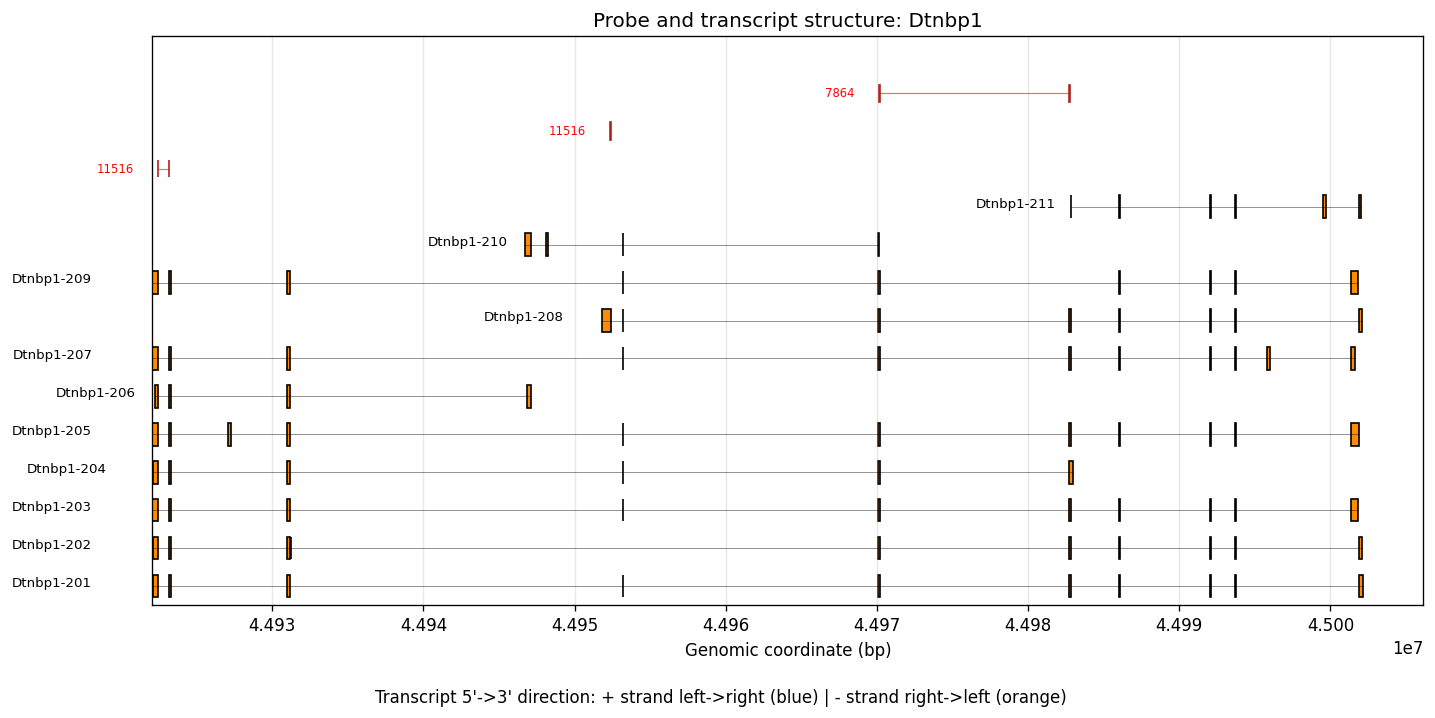

CPU times: user 7.89 s, sys: 84.2 ms, total: 7.98 s
Wall time: 8.03 s


In [24]:
%%time
plot_codeword_transcript_structure(
    gene_name="Dtnbp1",
    bed_file=bed_file,
    gtf_file=gtf_file,
)

## Method comparison: `SplisosmFFT` vs `SplisosmNP`

We now compare FFT-accelerated and non-parametric spatial variability tests on the same `AnnData` table.

**Note: The low-rank SV path (previously the default for `n>5000`) is no longer the default**. 
Null cumulants are now estimated from the **full-rank** spatial kernel using Hutchinson's trace estimator.
Use `null_configs={"n_probes": m}` to control the Hutchinson trace budget. A smaller `m` reduces runtime but may decrease accuracy.

If you need to reproduce the legacy low-rank behavior, you can explicitly pass ``null_configs={"approx_rank": k}``. 
Note that this approximation prioritizes global pattern detection **at the expense of zero power to local variation**. 
If global patterns are your primary focus, we recommend using the full-rank test with a higher `rho` value (e.g., `0.999`) instead to balance sensitivity across a wider range of spatial patterns.

In [25]:
%%time
model_np = SplisosmNP(
    k_neighbors=4,
    rho=0.99,
    standardize_cov=False # turn off for faster runtime
)
model_np.setup_data(
    adata=sdata.tables[test_table],
    spatial_key='spatial',
    layer='counts',
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    min_component_size=10 # remove disconnected tissue fragments if any
)
model_np

CPU times: user 1.95 s, sys: 815 ms, total: 2.77 s
Wall time: 2.92 s


=== SplisosmNP
- Number of genes: 4972
- Number of spots: 144372
- Number of covariates: 0
- Average isoforms per gene: 2.1
=== Model configurations
- Spatial kernel source: spatial_key='spatial' (component-filtered)
- k_neighbors: 4, rho: 0.99
- Standardize spatial covariance: False
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

In [26]:
%%time
model_np.test_spatial_variability(
    method='hsic-ir',
    null_configs={"n_probes": 60},
    ratio_transformation='none',
    print_progress=True,
)

SV [hsic-ir]:   0%|          | 0/4972 [00:00<?, ?it/s]

SV [hsic-ir]:   1%|          | 30/4972 [00:00<00:23, 212.86it/s]

SV [hsic-ir]:   1%|          | 52/4972 [00:00<00:28, 172.57it/s]

SV [hsic-ir]:   1%|▏         | 70/4972 [00:00<00:34, 141.96it/s]

SV [hsic-ir]:   2%|▏         | 90/4972 [00:00<00:37, 128.92it/s]

...

SV [hsic-ir]: 100%|█████████▉| 4950/4972 [00:57<00:00, 85.85it/s]

SV [hsic-ir]: 100%|█████████▉| 4960/4972 [00:57<00:00, 85.78it/s]

SV [hsic-ir]: 100%|█████████▉| 4970/4972 [00:57<00:00, 85.15it/s]

SV [hsic-ir]: 100%|██████████| 4972/4972 [00:57<00:00, 86.45it/s]

CPU times: user 4min 40s, sys: 34.5 s, total: 5min 15s
Wall time: 58.9 s


In [27]:
sv_np = model_np.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
sv_np = sv_np.rename(columns={'pvalue': 'pvalue_np'})

comparison = sv_res_fft[['gene', 'pvalue']].copy()
comparison = comparison.rename(columns={'pvalue': 'pvalue_fft'})
comparison = comparison.merge(sv_np, on='gene', how='inner')

corr, _ = spearmanr(comparison['pvalue_fft'], comparison['pvalue_np'])

print(f'Genes tested in both methods: {len(comparison)}')
print(f'P-value correlation (Spearman rho): {corr:.4f}')

Genes tested in both methods: 4972
P-value correlation (Spearman rho): 0.9985


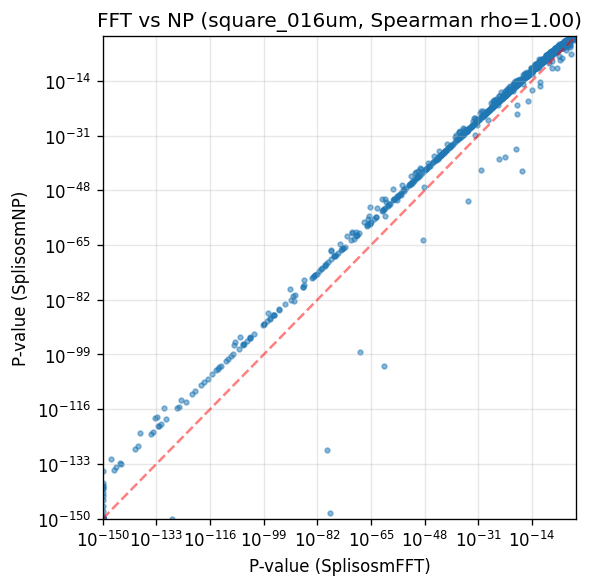

In [28]:
fig, ax = plt.subplots(figsize=(5, 5))
x = comparison['pvalue_fft'].to_numpy()
y = comparison['pvalue_np'].to_numpy()

ax.scatter(x + 1e-150, y + 1e-150, s=8, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('P-value (SplisosmFFT)')
ax.set_ylabel('P-value (SplisosmNP)')
ax.set_title(f'FFT vs NP ({test_table}, Spearman rho={corr:.2f})')
ax.grid(True, alpha=0.3)

lims = [1e-150, 1.0]
ax.plot(lims, lims, 'r--', alpha=0.5, linewidth=1.5)
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

## Summary

- `load_xenium_codeword` enables direct codeword-level multi-resolution binning from Xenium outputs.
- `SplisosmFFT` is an efficient default on regular square grids and yield highly similar results to `SplisosmNP`.

## For reproducibility

In [29]:
import sys
from datetime import date
import splisosm

print('Last updated:', date.today())
print('Python:', sys.version.split()[0])
print('splisosm:', getattr(splisosm, '__version__', 'unknown'))

Last updated: 2026-04-26
Python: 3.12.13
splisosm: 1.2.0rc1
